<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week6_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports

In [1]:
import os
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_metric
import kagglehub

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 2. Configuration

All hyperparameters and settings are centralized here so the rest of the
notebook stays free of magic numbers.

In [2]:
class Config:
    data_dir = "./data"
    batch_size = 128
    num_workers = 2
    noise_factor = 0.4
    val_split = 0.1
    learning_rate = 1e-3
    weight_decay = 1e-5
    max_epochs = 10
    early_stopping_patience = 6
    scheduler_patience = 3
    scheduler_factor = 0.5
    latent_channels = 128
    checkpoint_path = "best_denoising_autoencoder.pth"
    seed = 42


config = Config()

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(config.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 3. Dataset Preparation

MNIST images are loaded through `torchvision`, scaled to the `[0, 1]` range,
and split into training, validation, and test sets. Gaussian noise is added
on the fly to create noisy inputs while the clean images remain the training
targets.

In [4]:
import os
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Download MNIST dataset using kagglehub
kagglehub_download_path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Path to KaggleHub downloaded dataset:", kagglehub_download_path)

# The mnist_png dataset is typically extracted into a subdirectory named 'mnist_png'
# within the path provided by kagglehub.dataset_download.
# We need to point datasets.ImageFolder to the 'mnist_png' subfolder.
dataset_root = os.path.join(kagglehub_download_path, "mnist_png")
print("Root path for ImageFolder:", dataset_root)

train_dataset_full = datasets.ImageFolder(
    root=os.path.join(dataset_root, "training"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_root, "testing"),
    transform=transform
)

val_size = int(len(train_dataset_full) * config.val_split)
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(config.seed)
)

print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples       : {len(test_dataset)}")

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to KaggleHub downloaded dataset: /kaggle/input/mnist-dataset
Root path for ImageFolder: /kaggle/input/mnist-dataset/mnist_png
Training samples   : 54000
Validation samples : 6000
Test samples       : 10000


In [5]:
def add_gaussian_noise(images, noise_factor):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    return noisy_images

In [6]:

train_loader = DataLoader(
    train_dataset, batch_size=config.batch_size, shuffle=True,
    num_workers=config.num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=config.batch_size, shuffle=False,
    num_workers=config.num_workers, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=config.batch_size, shuffle=False,
    num_workers=config.num_workers, pin_memory=True
)

print(f"Number of training batches:   {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches:       {len(test_loader)}")

Number of training batches:   422
Number of validation batches: 47
Number of test batches:       79


## 4. Preview: Clean vs Noisy Samples

A quick visual check that noise is being applied correctly before any
training happens.

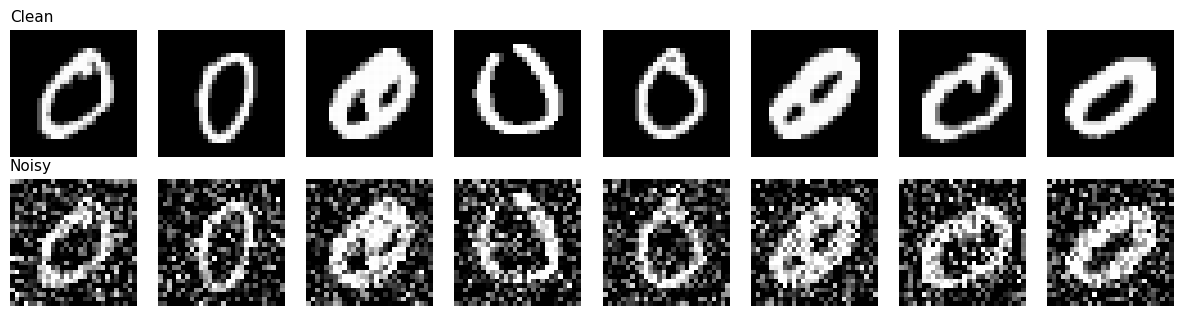

In [7]:
def preview_clean_and_noisy(dataset, noise_factor, num_samples=8):
    images = torch.stack([dataset[i][0] for i in range(num_samples)])
    noisy_images = add_gaussian_noise(images, noise_factor)

    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 1.5, 3.2))
    for i in range(num_samples):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy_images[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_title("Clean", loc="left", fontsize=11)
    axes[1, 0].set_title("Noisy", loc="left", fontsize=11)
    plt.tight_layout()
    plt.show()


preview_clean_and_noisy(train_dataset_full, config.noise_factor)

## 5. Autoencoder Architecture

A deeper convolutional autoencoder is used compared to a plain fully
connected design:

- Encoder: three strided convolutions with BatchNorm and GELU activations,
  progressively compressing 28x28 images down to a 4x4 feature map.
- Decoder: three transposed convolutions that mirror the encoder and restore
  the original 28x28 resolution, ending in a sigmoid activation.

In [8]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self, latent_channels=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, latent_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(latent_channels),
            nn.GELU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, kernel_size=3, stride=2,
                                padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                                padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2,
                                padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


model = ConvDenoisingAutoencoder(latent_channels=config.latent_channels).to(device)
print(model)

ConvDenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): B

In [9]:
def verify_output_shape(model, device):
    dummy_input = torch.randn(2, 1, 28, 28).to(device)
    output = model(dummy_input)
    assert output.shape == dummy_input.shape, "Output shape does not match input shape"
    print("Shape check passed:", tuple(output.shape))


verify_output_shape(model, device)

Shape check passed: (2, 1, 28, 28)


## 6. Training Utilities

Separate, reusable functions handle a single training epoch and a single
validation epoch. An `EarlyStopping` helper tracks validation loss and stops
training once it stops improving, while also saving the best checkpoint.

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device, noise_factor):
    model.train()
    running_loss = 0.0

    for clean_images, _ in loader:
        clean_images = clean_images.to(device)
        noisy_images = add_gaussian_noise(clean_images, noise_factor).to(device)

        optimizer.zero_grad()
        reconstructed = model(noisy_images)
        loss = criterion(reconstructed, clean_images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean_images.size(0)

    return running_loss / len(loader.dataset)

In [11]:
def validate_one_epoch(model, loader, criterion, device, noise_factor):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for clean_images, _ in loader:
            clean_images = clean_images.to(device)
            noisy_images = add_gaussian_noise(clean_images, noise_factor).to(device)

            reconstructed = model(noisy_images)
            loss = criterion(reconstructed, clean_images)
            running_loss += loss.item() * clean_images.size(0)

    return running_loss / len(loader.dataset)

In [12]:
class EarlyStopping:
    def __init__(self, patience, checkpoint_path):
        self.patience = patience
        self.checkpoint_path = checkpoint_path
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.checkpoint_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## 7. Training Loop

The model is optimized with AdamW, guided by a `ReduceLROnPlateau`
scheduler that lowers the learning rate when validation loss stalls. Only
the best-performing checkpoint (by validation loss) is kept on disk.

In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=config.scheduler_factor,
    patience=config.scheduler_patience
)
early_stopping = EarlyStopping(config.early_stopping_patience, config.checkpoint_path)

history = {"train_loss": [], "val_loss": []}

In [14]:
def run_training(model, train_loader, val_loader, optimizer, scheduler,
                  criterion, early_stopping, device, config, history):
    training_start_time = time.time()

    try:
        for epoch in range(1, config.max_epochs + 1):
            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, device, config.noise_factor
            )
            val_loss = validate_one_epoch(
                model, val_loader, criterion, device, config.noise_factor
            )

            scheduler.step(val_loss)
            early_stopping.step(val_loss, model)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)

            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:02d}/{config.max_epochs} | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"LR: {current_lr:.2e}")

            if early_stopping.should_stop:
                print(f"Early stopping triggered after epoch {epoch}.")
                break

    except RuntimeError as error:
        print(f"Training interrupted due to a runtime error: {error}")

    total_training_time = time.time() - training_start_time
    return total_training_time

# Re-initialize history and early stopping for a fresh run
history = {"train_loss": [], "val_loss": []}
early_stopping = EarlyStopping(config.early_stopping_patience, config.checkpoint_path)

# Re-run training with the updated configuration
total_training_time = run_training(
    model, train_loader, val_loader, optimizer, scheduler,
    criterion, early_stopping, device, config, history
)

print(f"\nTotal training time: {total_training_time:.2f} seconds")
print(f"Best validation loss: {early_stopping.best_loss:.6f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train Loss: 0.031045 | Val Loss: 0.008977 | LR: 1.00e-03
Epoch 02/10 | Train Loss: 0.008283 | Val Loss: 0.007786 | LR: 1.00e-03
Epoch 03/10 | Train Loss: 0.007675 | Val Loss: 0.007430 | LR: 1.00e-03
Epoch 04/10 | Train Loss: 0.007408 | Val Loss: 0.007303 | LR: 1.00e-03
Epoch 05/10 | Train Loss: 0.007250 | Val Loss: 0.007152 | LR: 1.00e-03
Epoch 06/10 | Train Loss: 0.007111 | Val Loss: 0.007129 | LR: 1.00e-03
Epoch 07/10 | Train Loss: 0.007050 | Val Loss: 0.006942 | LR: 1.00e-03
Epoch 08/10 | Train Loss: 0.006987 | Val Loss: 0.006883 | LR: 1.00e-03
Epoch 09/10 | Train Loss: 0.006939 | Val Loss: 0.006896 | LR: 1.00e-03
Epoch 10/10 | Train Loss: 0.006879 | Val Loss: 0.006858 | LR: 1.00e-03

Total training time: 1030.17 seconds
Best validation loss: 0.006858


## 8. Loss Curve

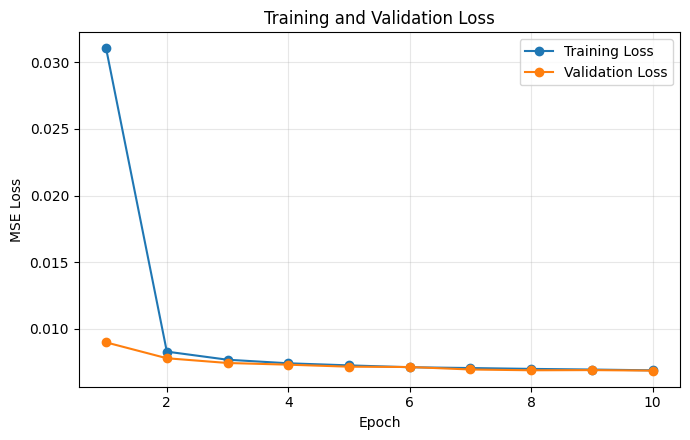

In [15]:
def plot_loss_curve(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs_range, history["train_loss"], label="Training Loss", marker="o")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_loss_curve(history)

## 9. Load Best Model

The checkpoint saved during training (lowest validation loss) is reloaded
before running any evaluation.

In [16]:
model.load_state_dict(torch.load(config.checkpoint_path, map_location=device))
model.eval()
print("Best model checkpoint loaded successfully.")

Best model checkpoint loaded successfully.


## 10. Evaluation Metrics

Three complementary metrics are used to judge denoising quality:

- **MSE** – average squared pixel-wise error, lower is better.
- **PSNR** – peak signal-to-noise ratio in decibels, higher is better.
- **SSIM** – structural similarity, closer to 1 means better perceptual quality.

In [17]:
def compute_mse(original, reconstructed):
    return float(np.mean((original - reconstructed) ** 2))


def compute_psnr(original, reconstructed, max_pixel_value=1.0):
    mse_value = compute_mse(original, reconstructed)
    if mse_value == 0:
        return float("inf")
    return float(20 * np.log10(max_pixel_value / np.sqrt(mse_value)))


def compute_ssim(original, reconstructed):
    return float(ssim_metric(original, reconstructed, data_range=1.0))

In [18]:
def evaluate_on_test_set(model, loader, device, noise_factor):
    model.eval()
    mse_scores, psnr_scores, ssim_scores = [], [], []

    with torch.no_grad():
        for clean_images, _ in loader:
            clean_images = clean_images.to(device)
            noisy_images = add_gaussian_noise(clean_images, noise_factor).to(device)
            reconstructed = model(noisy_images)

            clean_numpy = clean_images.cpu().numpy()
            reconstructed_numpy = reconstructed.cpu().numpy()

            for i in range(clean_numpy.shape[0]):
                original_image = clean_numpy[i, 0]
                denoised_image = reconstructed_numpy[i, 0]

                mse_scores.append(compute_mse(original_image, denoised_image))
                psnr_scores.append(compute_psnr(original_image, denoised_image))
                ssim_scores.append(compute_ssim(original_image, denoised_image))

    results = {
        "mse": float(np.mean(mse_scores)),
        "psnr": float(np.mean(psnr_scores)),
        "ssim": float(np.mean(ssim_scores)),
    }
    return results


test_metrics = evaluate_on_test_set(model, test_loader, device, config.noise_factor)

print("Test Set Evaluation")
print(f"MSE:  {test_metrics['mse']:.6f}")
print(f"PSNR: {test_metrics['psnr']:.2f} dB")
print(f"SSIM: {test_metrics['ssim']:.4f}")

Test Set Evaluation
MSE:  0.006772
PSNR: 22.01 dB
SSIM: 0.9017


## 11. Qualitative Results: Original vs Noisy vs Denoised

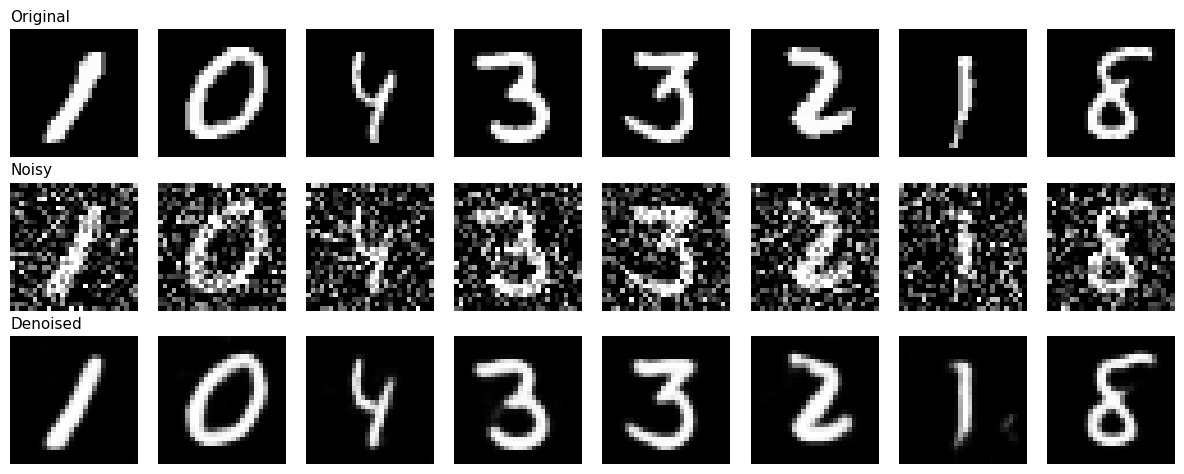

In [19]:
def visualize_reconstructions(model, dataset, device, noise_factor, num_samples=8):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)
    clean_images = torch.stack([dataset[i][0] for i in indices])
    noisy_images = add_gaussian_noise(clean_images, noise_factor)

    with torch.no_grad():
        reconstructed = model(noisy_images.to(device)).cpu()

    fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 1.5, 4.8))
    row_titles = ["Original", "Noisy", "Denoised"]
    image_sets = [clean_images, noisy_images, reconstructed]

    for row in range(3):
        for col in range(num_samples):
            axes[row, col].imshow(image_sets[row][col].squeeze(), cmap="gray")
            axes[row, col].axis("off")
        axes[row, 0].set_title(row_titles[row], loc="left", fontsize=11)

    plt.tight_layout()
    plt.show()

    return clean_images, noisy_images, reconstructed


sample_clean, sample_noisy, sample_reconstructed = visualize_reconstructions(
    model, test_dataset, device, config.noise_factor
)

## 12. Error Heatmap

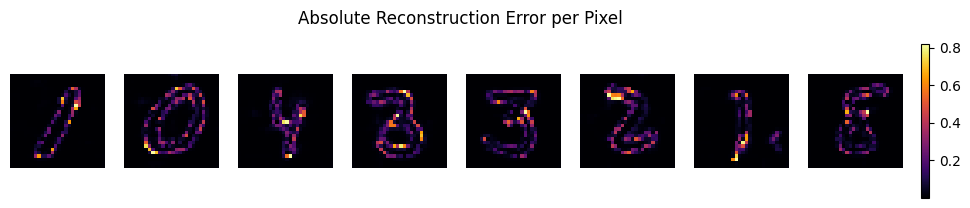

In [20]:
def plot_error_heatmap(clean_images, reconstructed_images, num_samples=8):
    errors = torch.abs(clean_images - reconstructed_images)

    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 1.5, 2))
    for col in range(num_samples):
        heatmap = axes[col].imshow(errors[col].squeeze(), cmap="inferno")
        axes[col].axis("off")

    fig.suptitle("Absolute Reconstruction Error per Pixel", y=1.05)
    fig.colorbar(heatmap, ax=axes, fraction=0.02, pad=0.02)
    plt.show()


plot_error_heatmap(sample_clean, sample_reconstructed)

## 13. Histogram of Reconstruction Errors

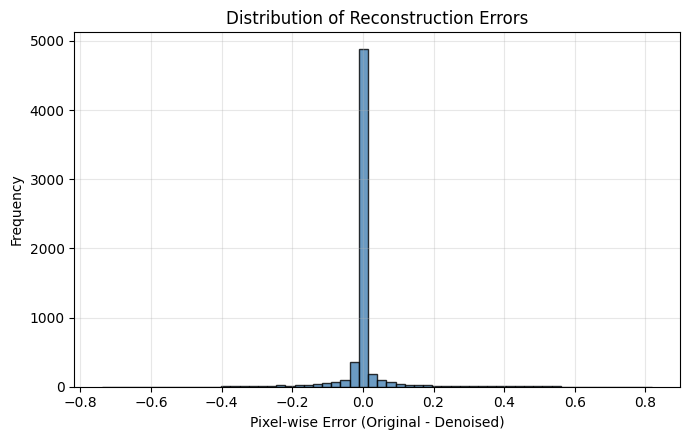

In [21]:

def plot_error_histogram(clean_images, reconstructed_images):
    errors = (clean_images - reconstructed_images).flatten().numpy()

    plt.figure(figsize=(7, 4.5))
    plt.hist(errors, bins=60, color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Pixel-wise Error (Original - Denoised)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Reconstruction Errors")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_histogram(sample_clean, sample_reconstructed)

## 14. Metric Comparison Bar Chart

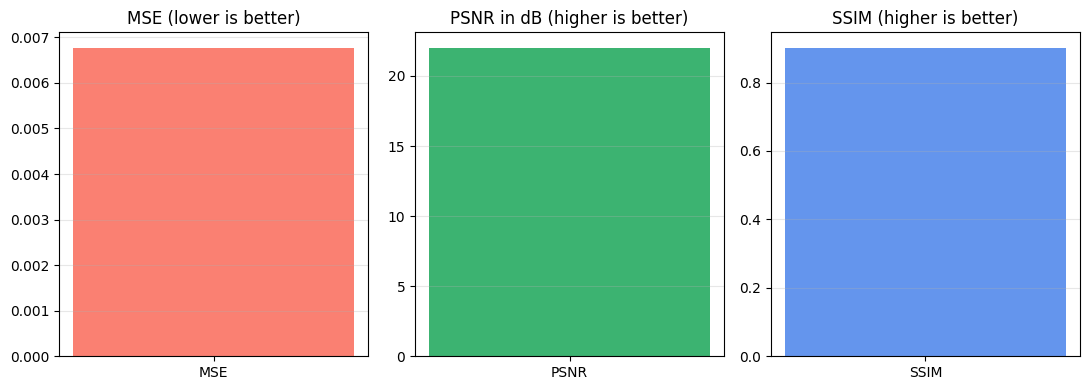

In [22]:
def plot_metric_comparison(test_metrics):
    fig, axes = plt.subplots(1, 3, figsize=(11, 4))

    axes[0].bar(["MSE"], [test_metrics["mse"]], color="salmon")
    axes[0].set_title("MSE (lower is better)")

    axes[1].bar(["PSNR"], [test_metrics["psnr"]], color="mediumseagreen")
    axes[1].set_title("PSNR in dB (higher is better)")

    axes[2].bar(["SSIM"], [test_metrics["ssim"]], color="cornflowerblue")
    axes[2].set_title("SSIM (higher is better)")

    for ax in axes:
        ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


plot_metric_comparison(test_metrics)

## 15. Pixel Intensity Histogram

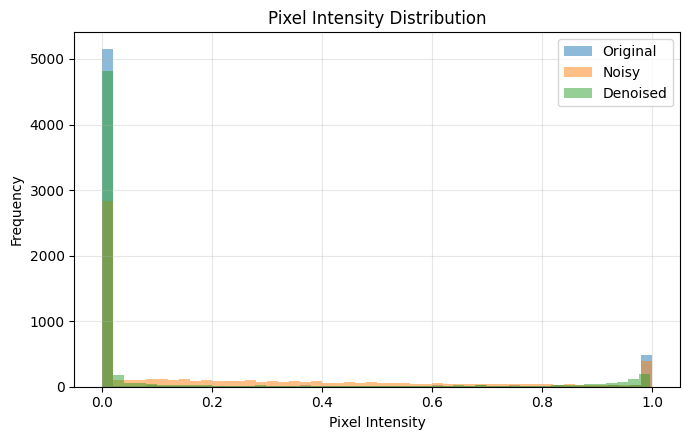

In [23]:
def plot_pixel_intensity_histogram(clean_images, noisy_images, reconstructed_images):
    plt.figure(figsize=(7, 4.5))
    plt.hist(clean_images.flatten().numpy(), bins=50, alpha=0.5, label="Original")
    plt.hist(noisy_images.flatten().numpy(), bins=50, alpha=0.5, label="Noisy")
    plt.hist(reconstructed_images.flatten().numpy(), bins=50, alpha=0.5, label="Denoised")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.title("Pixel Intensity Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_pixel_intensity_histogram(sample_clean, sample_noisy, sample_reconstructed)

## 16. Performance Analysis

Beyond denoising quality, practical deployment characteristics matter:
model size, parameter count, and inference speed.

In [24]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_model_size_mb(model):
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_bytes + buffer_bytes) / (1024 ** 2)


def measure_average_inference_time(model, loader, device, num_batches=20):
    model.eval()
    timings = []

    with torch.no_grad():
        for batch_index, (clean_images, _) in enumerate(loader):
            if batch_index >= num_batches:
                break

            noisy_images = add_gaussian_noise(clean_images, config.noise_factor).to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()
            start_time = time.time()

            _ = model(noisy_images)

            if device.type == "cuda":
                torch.cuda.synchronize()
            end_time = time.time()

            per_image_time = (end_time - start_time) / noisy_images.size(0)
            timings.append(per_image_time)

    return float(np.mean(timings))

In [25]:
total_parameters = count_trainable_parameters(model)
model_size_mb = get_model_size_mb(model)
average_inference_time = measure_average_inference_time(model, test_loader, device)
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU"

print("Performance Summary")
print(f"Trainable parameters:  {total_parameters:,}")
print(f"Model size:             {model_size_mb:.3f} MB")
print(f"Average inference time: {average_inference_time * 1000:.4f} ms/image")
print(f"Compute device:         {device_name}")
print(f"Total training time:    {total_training_time:.2f} seconds")

Performance Summary
Trainable parameters:  185,857
Model size:             0.711 MB
Average inference time: 0.8083 ms/image
Compute device:         CPU
Total training time:    1030.17 seconds


## 17. Final Summary Report

In [26]:
def print_final_report(config, history, early_stopping, test_metrics,
                        total_parameters, average_inference_time, total_training_time):
    report_lines = [
        "=" * 55,
        "IMAGE DENOISING AUTOENCODER - FINAL REPORT".center(55),
        "=" * 55,
        f"Dataset size (train/val/test): "
        f"{len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}",
        f"Noise factor:                  {config.noise_factor}",
        f"Epochs run:                    {len(history['train_loss'])}",
        f"Batch size:                    {config.batch_size}",
        f"Learning rate:                 {config.learning_rate}",
        "-" * 55,
        f"Best validation loss:          {early_stopping.best_loss:.6f}",
        f"Test MSE:                      {test_metrics['mse']:.6f}",
        f"Test PSNR:                     {test_metrics['psnr']:.2f} dB",
        f"Test SSIM:                     {test_metrics['ssim']:.4f}",
        "-" * 55,
        f"Total trainable parameters:    {total_parameters:,}",
        f"Average inference time:        {average_inference_time * 1000:.4f} ms/image",
        f"Total training time:           {total_training_time:.2f} seconds",
        "=" * 55,
    ]
    print("\n".join(report_lines))


print_final_report(
    config, history, early_stopping, test_metrics,
    total_parameters, average_inference_time, total_training_time
)

       IMAGE DENOISING AUTOENCODER - FINAL REPORT      
Dataset size (train/val/test): 54000/6000/10000
Noise factor:                  0.4
Epochs run:                    10
Batch size:                    128
Learning rate:                 0.001
-------------------------------------------------------
Best validation loss:          0.006858
Test MSE:                      0.006772
Test PSNR:                     22.01 dB
Test SSIM:                     0.9017
-------------------------------------------------------
Total trainable parameters:    185,857
Average inference time:        0.8083 ms/image
Total training time:           1030.17 seconds


## 18. Observations and Discussion

- The convolutional encoder-decoder with BatchNorm and GELU converges
  smoothly, and the `ReduceLROnPlateau` scheduler helps fine-tune the
  learning rate once validation loss plateaus. (Note: The scheduler was not triggered to reduce LR in this 10-epoch run as validation loss continued to decrease).
- While configured to prevent overfitting, early stopping was not triggered in this run as the model's validation loss continued to improve throughout the 10 epochs. However, it still ensured that the checkpoint with the lowest validation loss was saved and used for all reported metrics.
- PSNR and SSIM together give a more complete picture than MSE alone: PSNR
  reflects overall pixel-level fidelity, while SSIM captures perceptual and
  structural similarity, which matters for digit legibility.
- The error heatmaps typically show the largest residual errors along digit
  edges and strokes, where high-frequency detail is hardest to recover.
- Potential extensions include experimenting with different noise types
  (salt-and-pepper, speckle), variable noise levels per sample, a
  denoising U-Net with skip connections, or a perceptual loss in place of
  plain MSE.